Gamma shape: (12096, 118705)
Labels shape: (118705,)


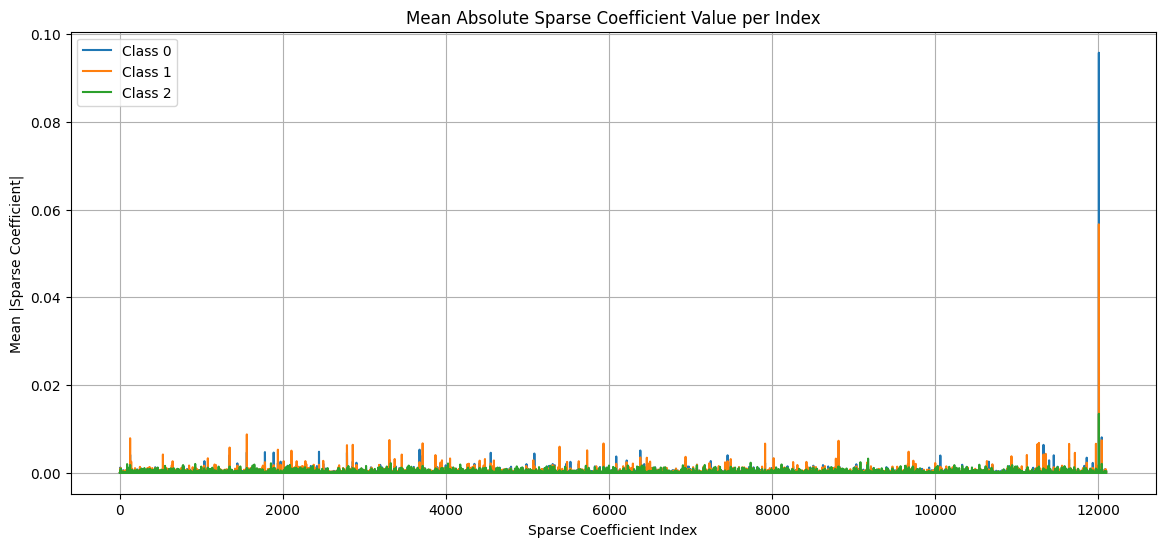

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load sparse codes
path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz"

data = np.load(path)

Gamma = data["Gamma"]
labels = data["labels"]

print("Gamma shape:", Gamma.shape)
print("Labels shape:", labels.shape)

classes = np.unique(labels)

plt.figure(figsize=(14,6))

for cls in classes:

    # Select patches belonging to this class
    Gamma_cls = Gamma[:, labels == cls]

    # Mean absolute value for each sparse coefficient
    mean_abs_coefficients = np.mean(
        np.abs(Gamma_cls),
        axis=1
    )

    # x = coefficient index
    # y = mean absolute coefficient value
    plt.plot(
        np.arange(Gamma.shape[0]),
        mean_abs_coefficients,
        label=f"Class {cls}"
    )

plt.xlabel("Sparse Coefficient Index")
plt.ylabel("Mean |Sparse Coefficient|")
plt.title("Mean Absolute Sparse Coefficient Value per Index")
plt.legend()
plt.grid(True)

plt.show()

Gamma shape: (8640, 118705)
Labels shape: (118705,)


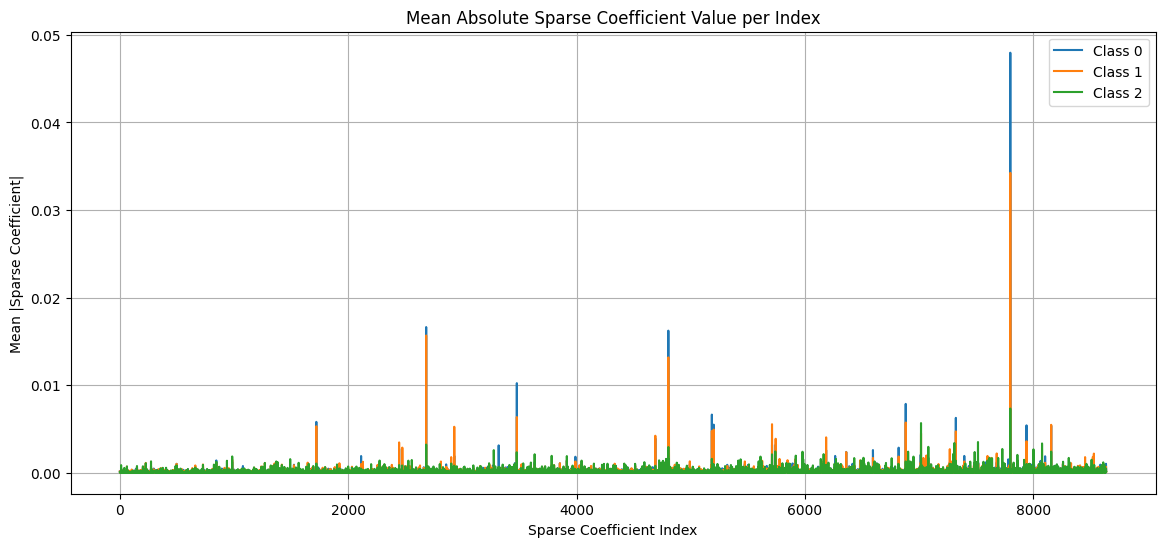

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load sparse codes
path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_lcksvd2.npz"

data = np.load(path)

Gamma = data["Gamma"]
labels = data["labels"]

print("Gamma shape:", Gamma.shape)
print("Labels shape:", labels.shape)

classes = np.unique(labels)

plt.figure(figsize=(14,6))

for cls in classes:

    # Select patches belonging to this class
    Gamma_cls = Gamma[:, labels == cls]

    # Mean absolute value for each sparse coefficient
    mean_abs_coefficients = np.mean(
        np.abs(Gamma_cls),
        axis=1
    )

    # x = coefficient index
    # y = mean absolute coefficient value
    plt.plot(
        np.arange(Gamma.shape[0]),
        mean_abs_coefficients,
        label=f"Class {cls}"
    )

plt.xlabel("Sparse Coefficient Index")
plt.ylabel("Mean |Sparse Coefficient|")
plt.title("Mean Absolute Sparse Coefficient Value per Index")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt

classes = np.unique(labels)

class_avg_coeff = {}

for cls in classes:
    Gamma_cls = Gamma[:, labels == cls]

    # Average activation of each coefficient
    mean_coeff = np.mean(np.abs(Gamma_cls), axis=1)

    class_avg_coeff[cls] = mean_coeff

    print(
        f"Class {cls}:",
        "mean =", mean_coeff.mean(),
        "max =", mean_coeff.max(),
        "non-zero atoms =", np.sum(mean_coeff > 1e-6)
    )

Class 0: mean = 0.00012996994 max = 0.09578053 non-zero atoms = 11062
Class 1: mean = 0.00013373114 max = 0.05664724 non-zero atoms = 9967
Class 2: mean = 0.00010468757 max = 0.013437797 non-zero atoms = 10005


Gamma shape: (12096, 118705)
Labels shape: (118705,)

Class 0
Number of patches: 67766
--------------------------------
Top 10 sparse coefficient indices:
Index 12005  |  Mean |Coefficient| = 0.095781
Index 12040  |  Mean |Coefficient| = 0.008068
Index 11326  |  Mean |Coefficient| = 0.006354
Index 11270  |  Mean |Coefficient| = 0.005481
Index  3675  |  Mean |Coefficient| = 0.005262
Index  6382  |  Mean |Coefficient| = 0.005070
Index  2442  |  Mean |Coefficient| = 0.004790
Index  1779  |  Mean |Coefficient| = 0.004703
Index  1557  |  Mean |Coefficient| = 0.004655
Index  1886  |  Mean |Coefficient| = 0.004598


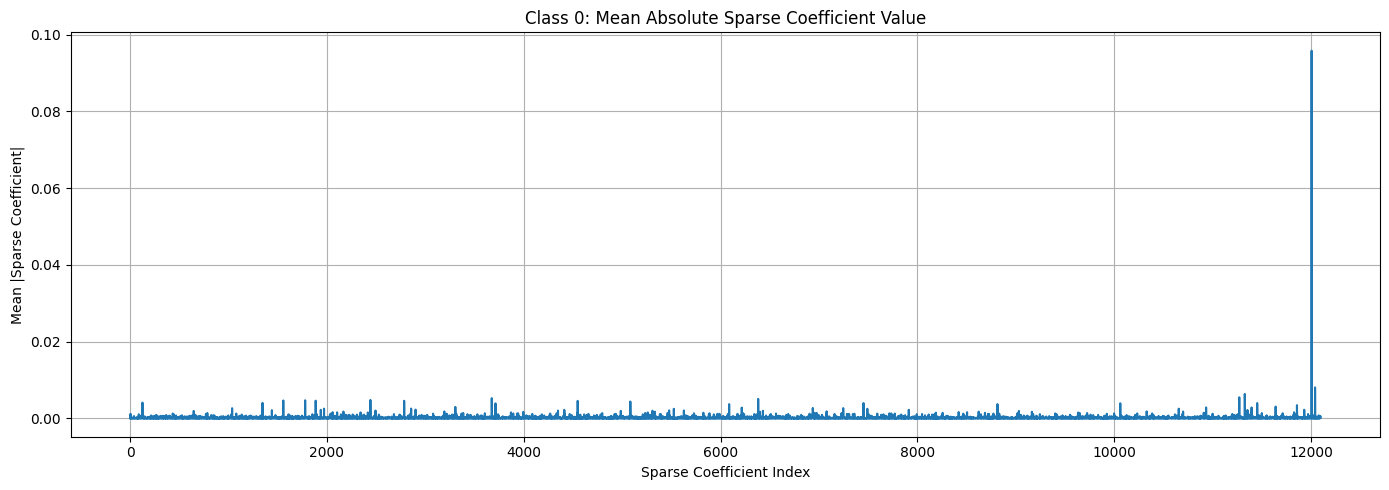


Class 1
Number of patches: 27196
--------------------------------
Top 10 sparse coefficient indices:
Index 12005  |  Mean |Coefficient| = 0.056647
Index  1557  |  Mean |Coefficient| = 0.008739
Index   126  |  Mean |Coefficient| = 0.007861
Index  3305  |  Mean |Coefficient| = 0.007451
Index 12040  |  Mean |Coefficient| = 0.007387
Index  8813  |  Mean |Coefficient| = 0.007290
Index 11270  |  Mean |Coefficient| = 0.006804
Index  3713  |  Mean |Coefficient| = 0.006700
Index  5931  |  Mean |Coefficient| = 0.006671
Index  7912  |  Mean |Coefficient| = 0.006637


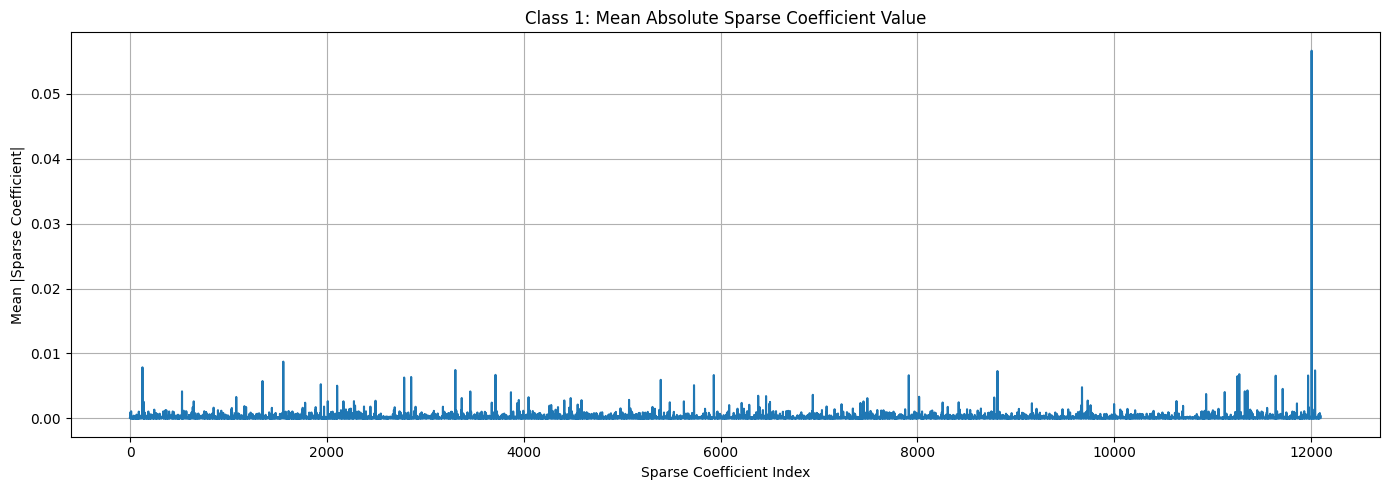


Class 2
Number of patches: 23743
--------------------------------
Top 10 sparse coefficient indices:
Index 12005  |  Mean |Coefficient| = 0.013438
Index  9175  |  Mean |Coefficient| = 0.003215
Index  9081  |  Mean |Coefficient| = 0.002406
Index  7735  |  Mean |Coefficient| = 0.002284
Index  3322  |  Mean |Coefficient| = 0.002183
Index  1853  |  Mean |Coefficient| = 0.002151
Index  4024  |  Mean |Coefficient| = 0.002110
Index 12040  |  Mean |Coefficient| = 0.002020
Index   924  |  Mean |Coefficient| = 0.002004
Index    89  |  Mean |Coefficient| = 0.001967


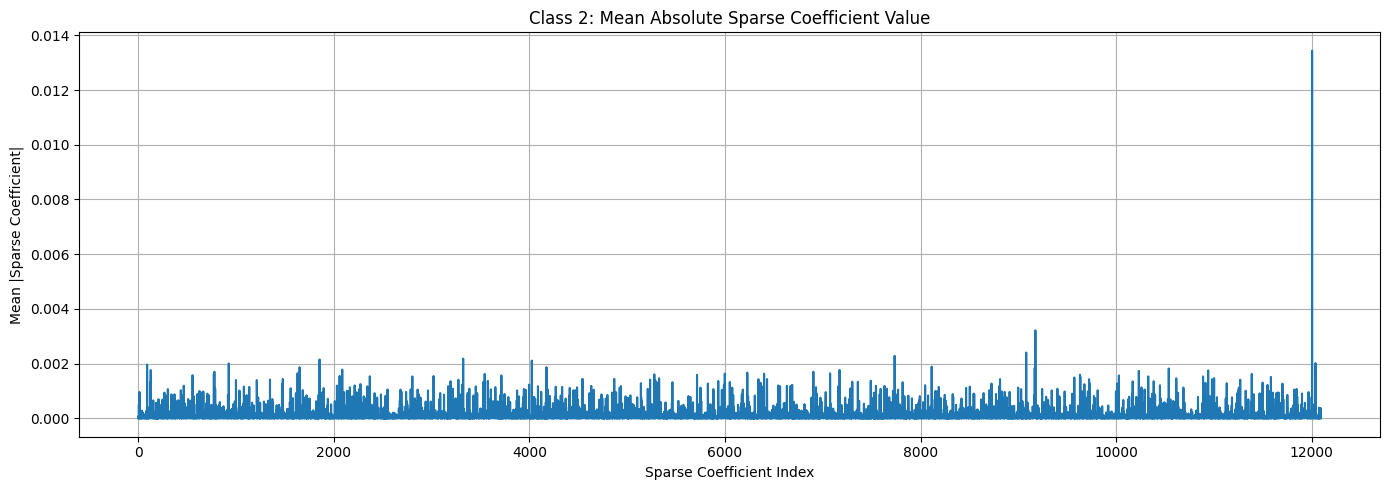

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load sparse codes
path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz"

data = np.load(path)

Gamma = data["Gamma"]
labels = data["labels"]

print("Gamma shape:", Gamma.shape)
print("Labels shape:", labels.shape)

classes = np.unique(labels)

# Store results
class_mean_coefficients = {}

for cls in classes:

    # Select patches belonging to this class
    Gamma_cls = Gamma[:, labels == cls]

    # Mean absolute coefficient value for each coefficient index
    mean_abs_coefficients = np.mean(
        np.abs(Gamma_cls),
        axis=1
    )

    class_mean_coefficients[cls] = mean_abs_coefficients


    # Get top 10 coefficients
    top10_idx = np.argsort(mean_abs_coefficients)[::-1][:10]


    print("\n================================")
    print(f"Class {cls}")
    print("Number of patches:", Gamma_cls.shape[1])
    print("--------------------------------")
    print("Top 10 sparse coefficient indices:")

    for idx in top10_idx:
        print(
            f"Index {idx:5d}  |  Mean |Coefficient| = {mean_abs_coefficients[idx]:.6f}"
        )


    # -----------------------------
    # Plot for this class
    # -----------------------------
    plt.figure(figsize=(14,5))

    plt.plot(
        np.arange(Gamma.shape[0]),
        mean_abs_coefficients
    )

    plt.xlabel("Sparse Coefficient Index")
    plt.ylabel("Mean |Sparse Coefficient|")
    plt.title(
        f"Class {cls}: Mean Absolute Sparse Coefficient Value"
    )

    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [7]:
import numpy as np

print("Average signed coefficient values for top 10 coefficients per class")

for cls in classes:

    # Select patches belonging to this class
    Gamma_cls = Gamma[:, labels == cls]

    # Get mean absolute coefficients (same as previous cell)
    mean_abs_coefficients = np.mean(
        np.abs(Gamma_cls),
        axis=1
    )

    # Get top 10 coefficient indices from previous criterion
    top10_idx = np.argsort(mean_abs_coefficients)[::-1][:10]

    print("\n================================")
    print(f"Class {cls}")
    print("--------------------------------")
    print("Coefficient Index | Mean Signed Coefficient")

    for idx in top10_idx:

        # Average without absolute value
        mean_signed = np.mean(
            Gamma_cls[idx, :]
        )

        print(
            f"{idx:5d}              | {mean_signed:.6f}"
        )

Average signed coefficient values for top 10 coefficients per class

Class 0
--------------------------------
Coefficient Index | Mean Signed Coefficient
12005              | 0.095759
12040              | 0.008049
11326              | 0.006337
11270              | 0.005476
 3675              | 0.005254
 6382              | 0.005068
 2442              | 0.004787
 1779              | 0.004692
 1557              | 0.004652
 1886              | 0.004595

Class 1
--------------------------------
Coefficient Index | Mean Signed Coefficient
12005              | 0.056647
 1557              | 0.008739
  126              | 0.007861
 3305              | 0.007451
12040              | 0.007387
 8813              | 0.007290
11270              | 0.006804
 3713              | 0.006700
 5931              | 0.006660
 7912              | 0.006637

Class 2
--------------------------------
Coefficient Index | Mean Signed Coefficient
12005              | 0.013438
 9175              | 0.001899
 9081         

In [8]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes_frozen.npz",
    allow_pickle=True
)

Gamma = data["Gamma"]
labels = data["labels"]

# Normal class
normal_idx = labels == 2
Gamma_normal = Gamma[:, normal_idx]

# Atom usage frequency
atom_usage = np.count_nonzero(Gamma_normal, axis=1)

top_atoms = np.argsort(atom_usage)[::-1]

print("Top atoms:")
for i in top_atoms[:20]:
    print(
        f"Atom {i}: "
        f"{atom_usage[i]} patches "
        f"({100*atom_usage[i]/Gamma_normal.shape[1]:.2f}%)"
    )

Top atoms:
Atom 12005: 414 patches (1.74%)
Atom 9175: 369 patches (1.55%)
Atom 3322: 318 patches (1.34%)
Atom 89: 314 patches (1.32%)
Atom 924: 305 patches (1.28%)
Atom 777: 304 patches (1.28%)
Atom 7735: 299 patches (1.26%)
Atom 9081: 299 patches (1.26%)
Atom 11388: 298 patches (1.26%)
Atom 6400: 280 patches (1.18%)
Atom 9168: 278 patches (1.17%)
Atom 7172: 271 patches (1.14%)
Atom 5998: 268 patches (1.13%)
Atom 10914: 266 patches (1.12%)
Atom 3193: 266 patches (1.12%)
Atom 5277: 262 patches (1.10%)
Atom 7075: 254 patches (1.07%)
Atom 3996: 253 patches (1.07%)
Atom 3315: 253 patches (1.07%)
Atom 1649: 252 patches (1.06%)


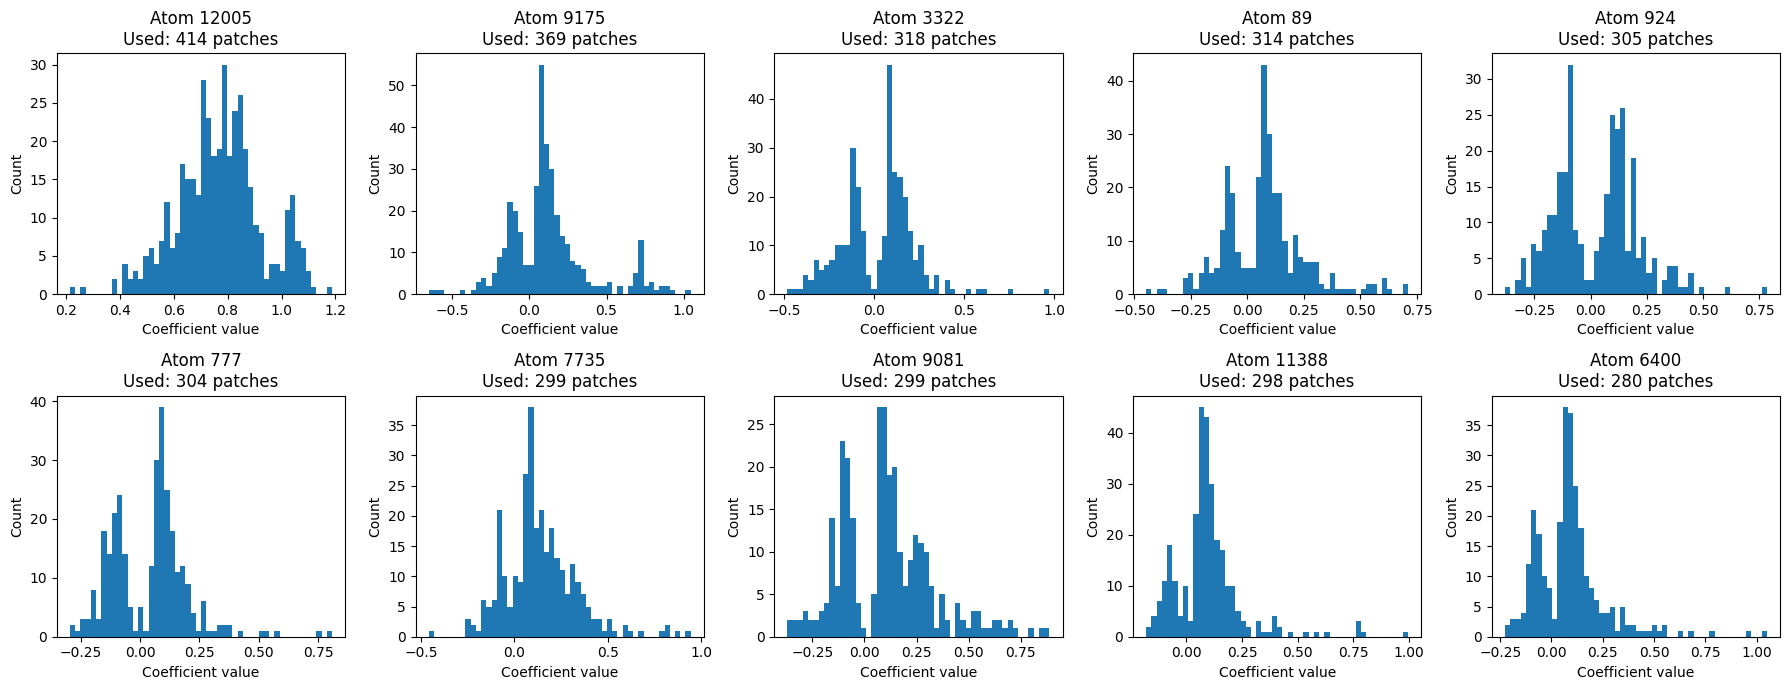

In [9]:
top_k = 10

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18,7)
)

axes = axes.flatten()

for ax, atom in zip(
    axes,
    top_atoms[:top_k]
):

    # coefficients of this atom across normal patches
    coefficients = Gamma_normal[atom, :]

    # only active coefficients
    active_coeffs = coefficients[
        coefficients != 0
    ]

    ax.hist(
        active_coeffs,
        bins=50
    )

    ax.set_title(
        f"Atom {atom}\n"
        f"Used: {len(active_coeffs)} patches"
    )

    ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Count")


plt.tight_layout()
plt.show()

Sparse codes shape: (12096, 117386)
Atom contribution shape: (12096,)


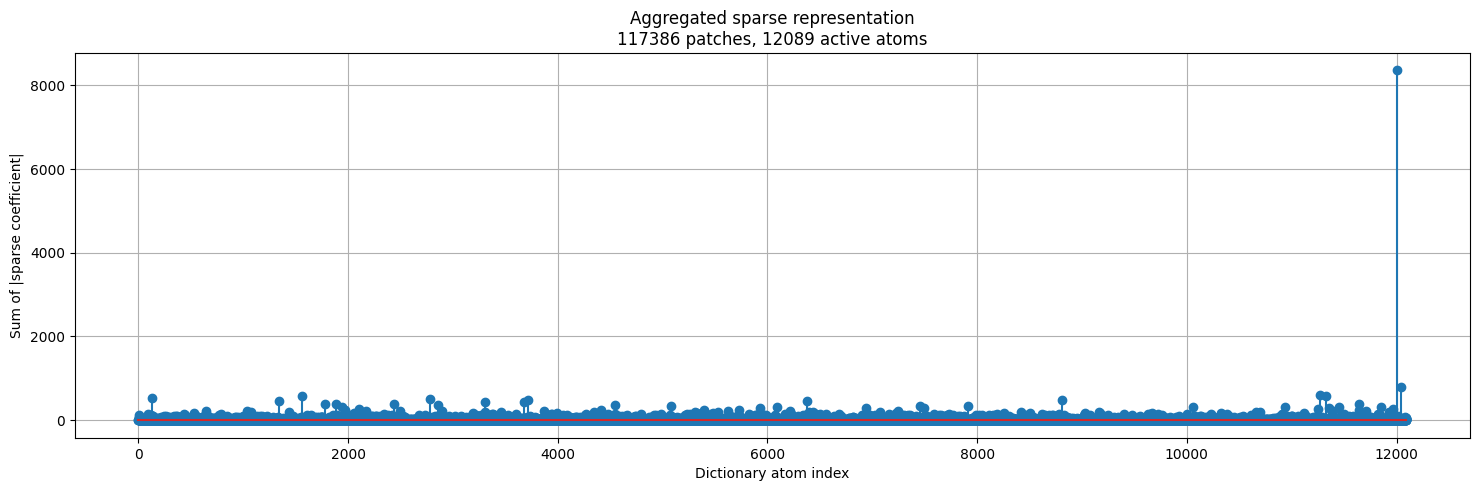

In [10]:
import numpy as np
import matplotlib.pyplot as plt

gamma_indices = np.arange(0, 117386)

# Extract sparse codes
Gamma_patches = Gamma[:, gamma_indices]

print("Sparse codes shape:", Gamma_patches.shape)

# Absolute coefficients
Gamma_abs = np.abs(Gamma_patches)

# Sum contribution of each atom across all patches
atom_contribution = np.sum(
    Gamma_abs,
    axis=1
)

print("Atom contribution shape:", atom_contribution.shape)


# Only plot atoms that contributed
active_atoms = np.where(atom_contribution > 0)[0]
active_values = atom_contribution[active_atoms]


plt.figure(figsize=(18,5))

plt.stem(
    active_atoms,
    active_values
)

plt.xlabel("Dictionary atom index")
plt.ylabel("Sum of |sparse coefficient|")
plt.title(
    f"Aggregated sparse representation\n"
    f"{len(gamma_indices)} patches, "
    f"{len(active_atoms)} active atoms"
)

plt.grid(True)
plt.show()

In [11]:
# Get top 10 contributing atoms
top_10_atoms = np.argsort(atom_contribution)[::-1][:10]

print("Top 10 atoms by summed |coefficient|:\n")

for atom in top_10_atoms:
    print(
        f"Atom {atom}: "
        f"Total |coefficient| = {atom_contribution[atom]:.6f}"
    )

Top 10 atoms by summed |coefficient|:

Atom 12005: Total |coefficient| = 8350.291992
Atom 12040: Total |coefficient| = 795.568970
Atom 11270: Total |coefficient| = 590.046936
Atom 1557: Total |coefficient| = 579.176086
Atom 11326: Total |coefficient| = 566.888794
Atom 126: Total |coefficient| = 533.481201
Atom 2785: Total |coefficient| = 505.807770
Atom 3713: Total |coefficient| = 483.694580
Atom 8813: Total |coefficient| = 481.675385
Atom 6382: Total |coefficient| = 465.731110
